# Gaussian Copula for Portfolio Risk Analysis

This notebook demonstrates the implementation and usage of Gaussian copula for portfolio risk analysis. The Gaussian copula is widely used in finance as it provides a flexible way to model multivariate dependence structures while maintaining the simplicity of normal distributions.

Key features of this implementation:
- Transforms return data into pseudo-observations using empirical distribution
- Fits a Gaussian copula to capture the linear dependence structure between assets
- Calculates Value at Risk (VaR) and Conditional Value at Risk (CVaR)
- Handles portfolio weights and returns data efficiently

The Gaussian copula provides a straightforward approach to modeling multivariate dependence in financial returns, making it a fundamental tool for risk management and portfolio optimization.


## Setup

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Basic Statistics:
              AAPL         MSFT        GOOGL         AMZN
count  5233.000000  5233.000000  5233.000000  5233.000000
mean      0.001376     0.000782     0.000997     0.001183
std       0.020555     0.017031     0.019359     0.023929
min      -0.179196    -0.147390    -0.116341    -0.218220
25%      -0.008260    -0.007102    -0.008066    -0.009969
50%       0.001152     0.000485     0.000835     0.000643
75%       0.011748     0.008895     0.010213     0.012363
max       0.153288     0.186046     0.199915     0.269497


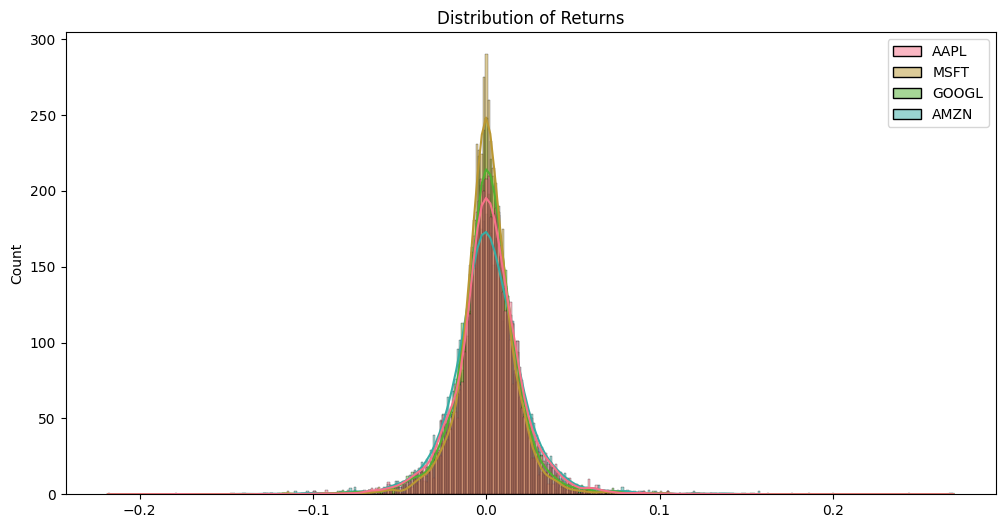

In [9]:
from helper import get_data
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_palette('husl')

df = get_data(["AAPL", "MSFT", "GOOGL", "AMZN"])
returns = df.pct_change().dropna()

# Basic statistics
print("Basic Statistics:")
print(returns.describe())


# Plot returns distribution
plt.figure(figsize=(12, 6))
sns.histplot(returns, kde=True)
plt.title('Distribution of Returns')
plt.show()

## Data Analysis and Visualization
 
In this section, we analyze the historical returns data for our selected stocks (AAPL, MSFT, GOOGL, AMZN). We've already:
- 1. Retrieved the data using Yahoo Finance API
- 2. Calculated daily returns using percentage change
- 3. Generated basic statistical summaries
- 4. Created a distribution plot of returns
# 
 The next section will focus on implementing the Gaussian copula model to capture the dependence structure between these assets and generate Monte Carlo simulations for risk analysis.


In [10]:
import numpy as np
from scipy.stats import norm

returns = returns.to_numpy()

(n_assets, size) = (returns.shape[1], 100000)

corr_matrix = np.corrcoef(returns, rowvar=False)
cholesky_matrix = np.linalg.cholesky(corr_matrix)

# Generate multivariate normal samples
Z = np.random.multivariate_normal(
    np.zeros(n_assets),
    np.eye(n_assets),
    size
)

X = Z.dot(cholesky_matrix.T)

# Transform to uniform using normal CDF
U = norm.cdf(X)

U_scaled = np.empty_like(U)
for i in range(n_assets):
    U_scaled[:, i] = np.quantile(returns[:, i], U[:, i])

- Plotting the dependency structure

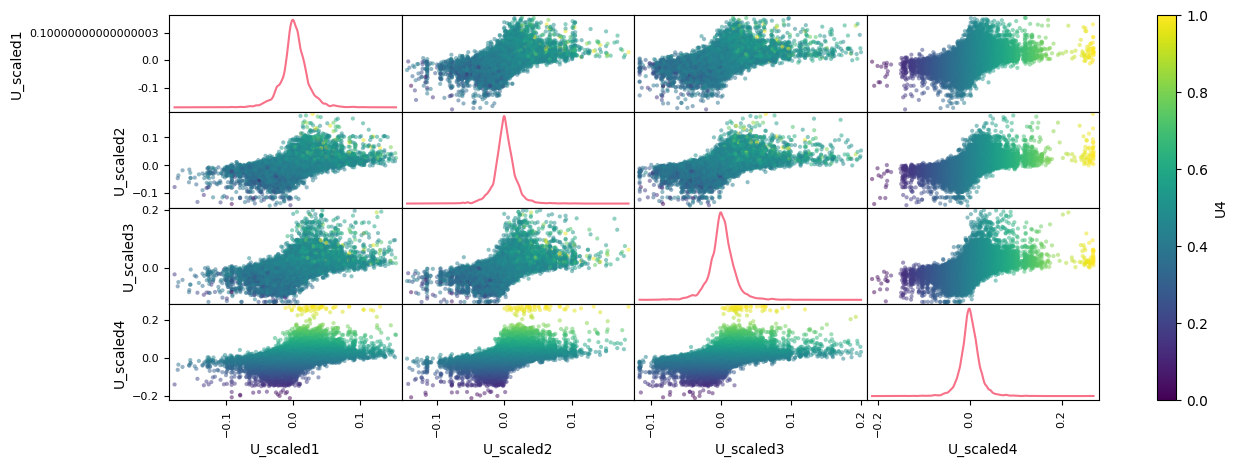

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(U_scaled)
df.columns = ["U_scaled1", "U_scaled2", "U_scaled3", "U_scaled4"]

# Use U4 as the color variable
colors = df["U_scaled4"]

# Create the scatter matrix with colors
pd.plotting.scatter_matrix(df, alpha=0.5, figsize=(15, 5), diagonal='kde', c=colors, cmap='viridis')

# Add a colorbar to show the mapping of color to U4
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gcf().axes)
cbar.set_label('U4')

plt.show()

## Dependency Structure Analysis
# 
This section visualizes the dependency structure between all assets in our portfolio. The analysis includes:
# 
- Scatter matrix plots showing pairwise relationships between assets
- 3D visualization of the first three assets with the fourth asset represented by color
- Correlation patterns and clustering behavior
- Identification of potential tail dependencies
# 
These visualizations help us understand how the assets move together and identify any non-linear relationships or extreme co-movements.

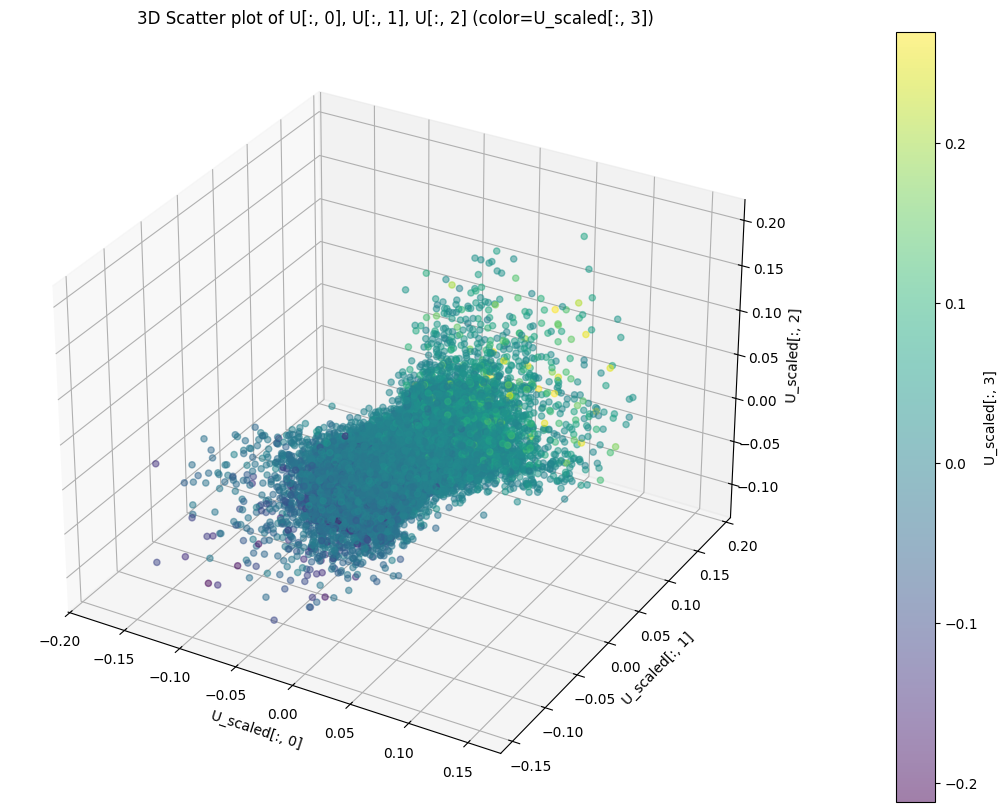

In [15]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# Use U[:, 3] as the color
sc = ax.scatter(U_scaled[:, 0], U_scaled[:, 1], U_scaled[:, 2], c=U_scaled[:, 3], cmap='viridis', alpha=0.5)
ax.set_xlabel('U_scaled[:, 0]')
ax.set_ylabel('U_scaled[:, 1]')
ax.set_zlabel('U_scaled[:, 2]')
ax.set_title('3D Scatter plot of U[:, 0], U[:, 1], U[:, 2] (color=U_scaled[:, 3])')

# Add a colorbar to show the mapping of color to U[:, 3]
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('U_scaled[:, 3]')

plt.show()

## Portfolio Risk Analysis

# 
In this section, we analyze the risk characteristics of an equally-weighted portfolio
composed of the four assets. We calculate key risk metrics including Value at Risk (VaR)
and Expected Shortfall (ES) at the 95% confidence level. The analysis includes:
# 
- Portfolio return distribution visualization
- VaR and ES calculations
- Q-Q plot for normality assessment
- Additional risk metrics (mean, standard deviation, skewness, kurtosis)
# 
This analysis helps us understand the portfolio's risk profile and potential tail risks.


Portfolio Statistics:
95% VaR: -0.0233
95% Expected Shortfall: -0.0338


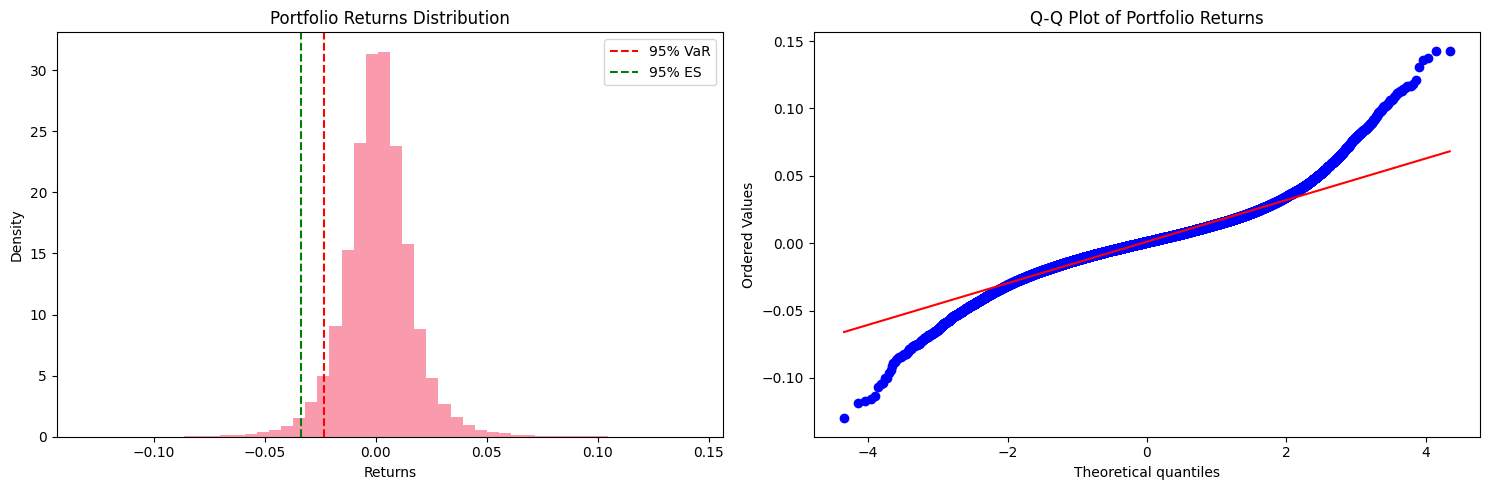


Additional Portfolio Metrics:
Mean Return: 0.0011
Standard Deviation: 0.0157
Skewness: 0.2582
Kurtosis: 3.9541


In [16]:
from scipy import stats

WEIGHTS = np.array([0.25, 0.25, 0.25, 0.25])

portfolio = np.dot(WEIGHTS, U_scaled.T)
# Calculate portfolio VaR and ES
VaR_95 = np.percentile(portfolio, 5)
ES_95 = np.mean(portfolio[portfolio <= VaR_95])

print(f"\nPortfolio Statistics:")
print(f"95% VaR: {VaR_95:.4f}")
print(f"95% Expected Shortfall: {ES_95:.4f}")

# Plot portfolio returns distribution
plt.figure(figsize=(15, 5))

# Histogram of portfolio returns
plt.subplot(121)
plt.hist(portfolio, bins=50, density=True, alpha=0.7)
plt.axvline(VaR_95, color='r', linestyle='dashed', label='95% VaR')
plt.axvline(ES_95, color='g', linestyle='dashed', label='95% ES')
plt.title('Portfolio Returns Distribution')
plt.xlabel('Returns')
plt.ylabel('Density')
plt.legend()

# QQ plot of portfolio returns
plt.subplot(122)
stats.probplot(portfolio, dist="norm", plot=plt)
plt.title('Q-Q Plot of Portfolio Returns')

plt.tight_layout()
plt.show()

# Calculate some additional portfolio metrics
print(f"\nAdditional Portfolio Metrics:")
print(f"Mean Return: {np.mean(portfolio):.4f}")
print(f"Standard Deviation: {np.std(portfolio):.4f}")
print(f"Skewness: {stats.skew(portfolio):.4f}")
print(f"Kurtosis: {stats.kurtosis(portfolio):.4f}")